In [1]:
import copy
import pathlib
from functools import reduce
import operator

import numpy as np
import matplotlib.pyplot as plt

import openmc

In [2]:
MODEL_XML = pathlib.Path('model.xml')
SHOW_OPENMC_OUTPUT = False
OPENMC_VERBOSITY = 7
WW_VOXEL_SIZE = 10.0
ANALYSIS_VOXEL_SIZE = 10.0
PARTICLES_PER_BATCH = 1000
BATCH_CHECKPOINTS = [10, 100, 1000]

In [3]:
openmc.reset_auto_ids()
base_model = openmc.Model.from_model_xml(MODEL_XML)
geometry = base_model.geometry
materials = base_model.materials
source = base_model.settings.source
mat1 = next(material for material in materials if material.id == 1)
mat1_cells = sorted(
    (cell for cell in geometry.get_all_cells().values() if cell.fill is mat1),
    key=lambda cell: cell.id,
)

In [4]:
mat1_bb = reduce(operator.or_, (cell.region.bounding_box for cell in mat1_cells))
MESH_LL = mat1_bb.lower_left.copy()
MESH_UR = mat1_bb.upper_right.copy()
MESH_RANGE = MESH_UR - MESH_LL
WW_DIM = np.round(MESH_RANGE / WW_VOXEL_SIZE).astype(int)
ANALYSIS_DIM = np.round(MESH_RANGE / ANALYSIS_VOXEL_SIZE).astype(int)

analysis_mesh = openmc.RegularMesh(name='analysis_mesh')
analysis_mesh.lower_left = MESH_LL
analysis_mesh.upper_right = MESH_UR
analysis_mesh.dimension = ANALYSIS_DIM.tolist()

cell_tally = openmc.Tally(name='cell_flux')
cell_tally.filters = [openmc.CellFilter(mat1_cells)]
cell_tally.scores = ['flux']
cell_tally.higher_moments = True

mesh_tally = openmc.Tally(name='mesh_flux')
mesh_tally.filters = [openmc.MeshFilter(analysis_mesh), openmc.EnergyFilter([0.0, 2.0e7])]
mesh_tally.scores = ['flux']
mesh_tally.higher_moments = True

Y_CELL_CENTERS = np.array([cell.region.bounding_box.center[1] for cell in mat1_cells])

In [5]:
FWCADIS_DIR = pathlib.Path('fwcadis_gen')
FWCADIS_DIR.mkdir(exist_ok=True)
MGXS_PATH = FWCADIS_DIR / 'mgxs.h5'
WW_FILE = FWCADIS_DIR / 'weight_windows.h5'

rr_model = copy.deepcopy(base_model)
rr_model.convert_to_multigroup(
    method='stochastic_slab',
    overwrite_mgxs_library=True,
    mgxs_path=str(MGXS_PATH),
    nparticles=2000,
    groups='ECCO-33'
)

/home/kosbor/miniconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=4.
  warn(msg, IDWarning)
/home/kosbor/miniconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=5.
  warn(msg, IDWarning)
/home/kosbor/miniconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=14.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [6]:
rr_model.convert_to_random_ray()
rr_model.settings.random_ray['distance_inactive'] = 0.0
rr_model.settings.random_ray['distance_active'] = 250.0
rr_model.settings.particles = 1000
rr_model.settings.batches = 100
rr_model.settings.inactive = 50
rr_model.settings.seed = 3
rr_model.settings.verbosity = OPENMC_VERBOSITY

rr_ww_mesh = openmc.RegularMesh(name='rr_ww_mesh')
rr_ww_mesh.lower_left = MESH_LL
rr_ww_mesh.upper_right = MESH_UR
rr_ww_mesh.dimension = WW_DIM.tolist()

rr_flux_tally = openmc.Tally(name='rr_flux')
rr_flux_tally.filters = [openmc.MeshFilter(rr_ww_mesh)]
rr_flux_tally.scores = ['flux']
rr_model.tallies = openmc.Tallies([rr_flux_tally])
rr_model.settings.random_ray['source_region_meshes'] = [
    (rr_ww_mesh, [rr_model.geometry.root_universe])
]
rr_model.settings.weight_window_generators = openmc.WeightWindowGenerator(
    method='fw_cadis', mesh=rr_ww_mesh,
)

In [7]:
rr_model.run(cwd=FWCADIS_DIR, output=SHOW_OPENMC_OUTPUT)

PosixPath('/mnt/c/Users/kosbor/programs/openmc-tests-structure/0.15.3/fundamental_testing/7222_seww/fwcadis_gen/statepoint.100.h5')

In [8]:
analysis_settings = openmc.Settings()
analysis_settings.run_mode = 'fixed source'
analysis_settings.particles = PARTICLES_PER_BATCH
analysis_settings.batches = BATCH_CHECKPOINTS[-1]
analysis_settings.seed = 5
analysis_settings.source = source
analysis_settings.survival_biasing = False
analysis_settings.output = {'tallies': False}
analysis_settings.statepoint = {'batches': BATCH_CHECKPOINTS}
analysis_settings.verbosity = OPENMC_VERBOSITY

In [9]:
ANALOG_DIR = pathlib.Path('analog')
ANALOG_DIR.mkdir(exist_ok=True)

In [10]:
analog_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=analysis_settings,
    tallies=openmc.Tallies([cell_tally, mesh_tally]),
)
analog_model.run(cwd=ANALOG_DIR, output=SHOW_OPENMC_OUTPUT)

PosixPath('/mnt/c/Users/kosbor/programs/openmc-tests-structure/0.15.3/fundamental_testing/7222_seww/analog/statepoint.1000.h5')

In [11]:
FWCADIS_SIM_DIR = pathlib.Path('fwcadis')
FWCADIS_SIM_DIR.mkdir(exist_ok=True)

In [12]:
fwcadis_ww_list = openmc.WeightWindowsList.from_hdf5(WW_FILE)
fwcadis_ww_list[0].max_split = 100
fwcadis_ww_list[0].survival_ratio = 3
fwcadis_settings = openmc.Settings()
fwcadis_settings.run_mode = 'fixed source'
fwcadis_settings.particles = PARTICLES_PER_BATCH
fwcadis_settings.batches = BATCH_CHECKPOINTS[-1]
fwcadis_settings.seed = 7
fwcadis_settings.source = source
fwcadis_settings.survival_biasing = False
fwcadis_settings.output = {'tallies': False}
fwcadis_settings.statepoint = {'batches': BATCH_CHECKPOINTS}
fwcadis_settings.verbosity = OPENMC_VERBOSITY
fwcadis_settings.weight_windows = fwcadis_ww_list
fwcadis_settings.weight_windows_on = True
fwcadis_settings.weight_window_checkpoints = {'collision': True, 'surface': True}
fwcadis_settings.max_history_splits = 100

fwcadis_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=fwcadis_settings,
    tallies=openmc.Tallies([cell_tally, mesh_tally]),
)
fwcadis_model.export_to_model_xml(path=FWCADIS_SIM_DIR)

/home/kosbor/miniconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=2.
  warn(msg, IDWarning)


In [13]:
fwcadis_model.run(cwd=FWCADIS_SIM_DIR, output=SHOW_OPENMC_OUTPUT)

PosixPath('/mnt/c/Users/kosbor/programs/openmc-tests-structure/0.15.3/fundamental_testing/7222_seww/fwcadis/statepoint.1000.h5')

In [14]:
def sp_path(run_dir, batch):
    return run_dir / f'statepoint.{batch:0{len(str(BATCH_CHECKPOINTS[-1]))}d}.h5'


def extract_stats(path, tally_name):
    with openmc.StatePoint(path) as sp:
        tally = sp.get_tally(name=tally_name)
        mean = tally.mean.ravel()
        std_dev = tally.std_dev.ravel()
        try:
            vov = tally.vov.ravel()
        except Exception:
            vov = np.full_like(mean, np.nan, dtype=float)
        return sp.n_realizations, mean, std_dev, vov


def avg_rel_err(mean, std_dev):
    valid = mean > 0
    return float(np.mean(std_dev[valid] / mean[valid])) if valid.any() else float('nan')


analog_records = []
fwcadis_records = []
for batch in BATCH_CHECKPOINTS:
    record_pairs = (
        (ANALOG_DIR, analog_records),
        (FWCADIS_SIM_DIR, fwcadis_records),
    )
    for run_dir, records in record_pairs:
        n_real, mean_cell, sd_cell, cell_vov = extract_stats(sp_path(run_dir, batch), 'cell_flux')
        _, mean_mesh, sd_mesh, _ = extract_stats(sp_path(run_dir, batch), 'mesh_flux')
        records.append({
            'N': batch * PARTICLES_PER_BATCH,
            'n_real': n_real,
            'avg_rel_err': avg_rel_err(mean_mesh, sd_mesh),
            'mean_cell': mean_cell,
            'sd_cell': sd_cell,
            'cell_vov': cell_vov,
        })

Ns = np.array([record['N'] for record in analog_records])
are_analog = np.array([record['avg_rel_err'] for record in analog_records])
are_fwcadis = np.array([record['avg_rel_err'] for record in fwcadis_records])

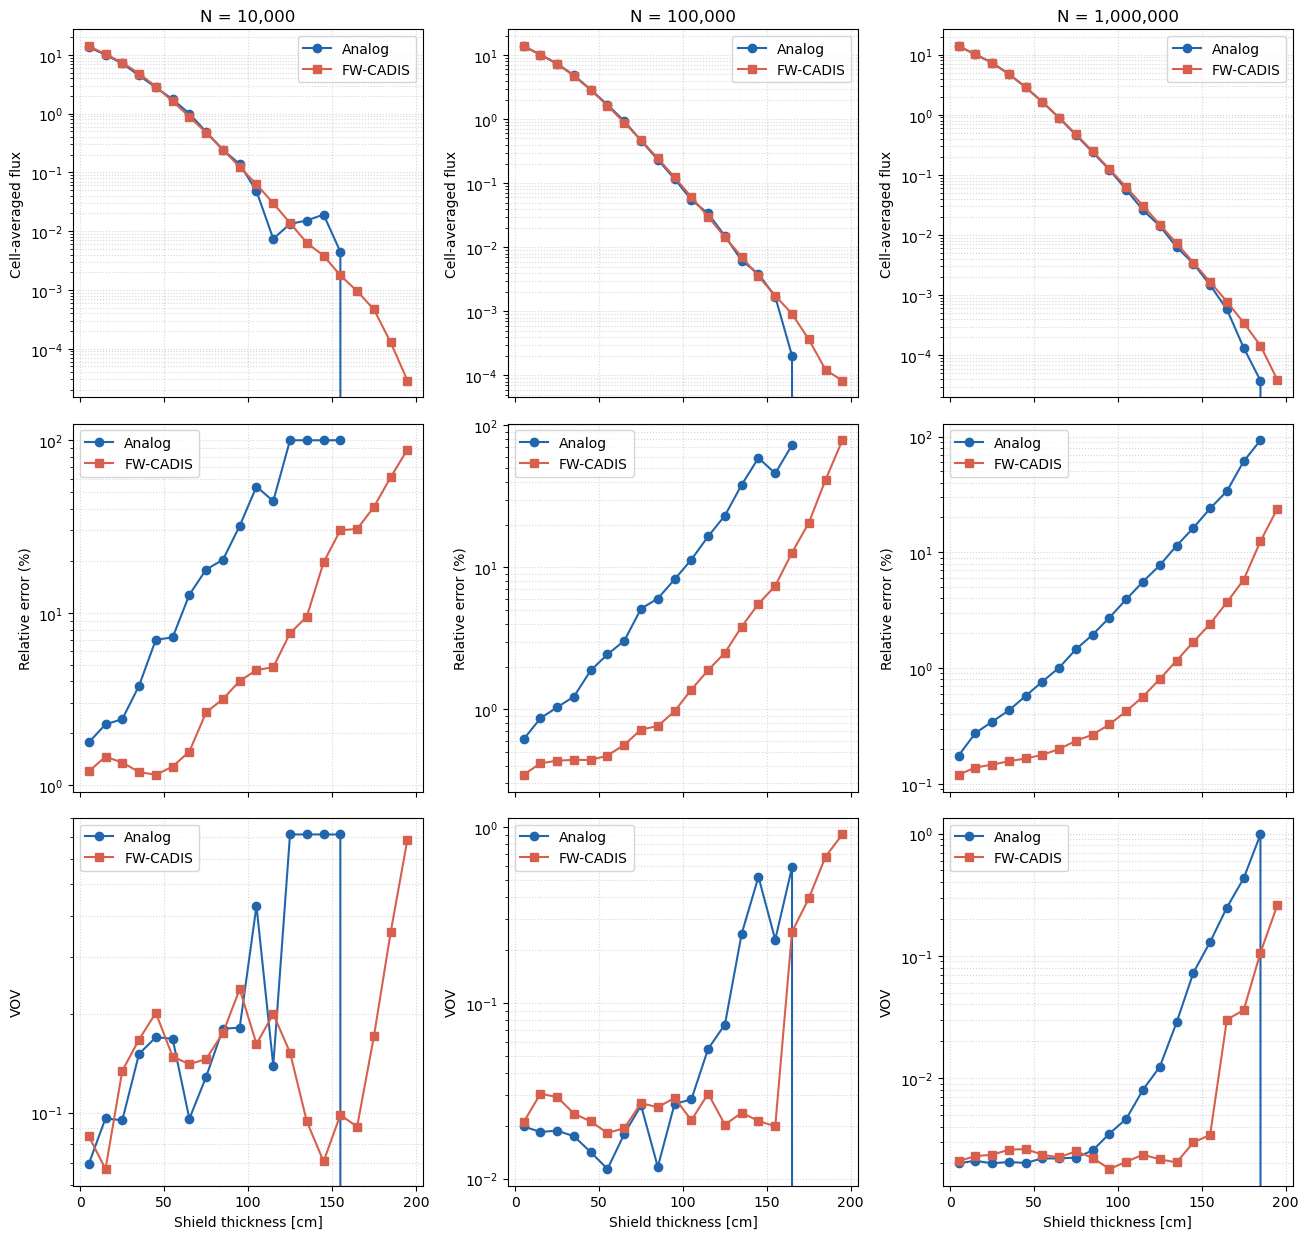

In [ ]:
mean_cell_analog = np.array([record['mean_cell'] for record in analog_records])
mean_cell_fwcadis = np.array([record['mean_cell'] for record in fwcadis_records])
sd_cell_analog = np.array([record['sd_cell'] for record in analog_records])
sd_cell_fwcadis = np.array([record['sd_cell'] for record in fwcadis_records])
vov_cell_analog = np.array([record['cell_vov'] for record in analog_records])
vov_cell_fwcadis = np.array([record['cell_vov'] for record in fwcadis_records])

re_cell_analog = np.full_like(mean_cell_analog, np.nan, dtype=float)
re_cell_fwcadis = np.full_like(mean_cell_fwcadis, np.nan, dtype=float)
np.divide(sd_cell_analog, mean_cell_analog, out=re_cell_analog, where=mean_cell_analog > 0)
np.divide(sd_cell_fwcadis, mean_cell_fwcadis, out=re_cell_fwcadis, where=mean_cell_fwcadis > 0)

n_cols = len(BATCH_CHECKPOINTS)
fig, axes = plt.subplots(3, n_cols, figsize=(4.4 * n_cols, 12.5), sharex='col')
if n_cols == 1:
    axes = np.array(axes).reshape(3, 1)

for index in range(n_cols):
    ax = axes[0, index]
    ax.semilogy(Y_CELL_CENTERS, mean_cell_analog[index], 'o-', color='#2166ac', ms=6, label='Analog')
    ax.semilogy(Y_CELL_CENTERS, mean_cell_fwcadis[index], 's-', color='#d6604d', ms=6, label='FW-CADIS')
    ax.set_ylabel('Cell-averaged flux')
    ax.set_title(f'N = {Ns[index]:,.0f}')
    ax.legend()
    ax.grid(True, which='both', ls=':', alpha=0.5)

    ax = axes[1, index]
    ax.semilogy(Y_CELL_CENTERS, re_cell_analog[index] * 100, 'o-', color='#2166ac', ms=6, label='Analog')
    ax.semilogy(Y_CELL_CENTERS, re_cell_fwcadis[index] * 100, 's-', color='#d6604d', ms=6, label='FW-CADIS')
    ax.set_ylabel('Relative error (%)')
    ax.legend()
    ax.grid(True, which='both', ls=':', alpha=0.5)

    ax = axes[2, index]
    ax.semilogy(Y_CELL_CENTERS, vov_cell_analog[index], 'o-', color='#2166ac', ms=6, label='Analog')
    ax.semilogy(Y_CELL_CENTERS, vov_cell_fwcadis[index], 's-', color='#d6604d', ms=6, label='FW-CADIS')
    ax.set_xlabel('Shield thickness [cm]')
    ax.set_ylabel('VOV')
    ax.legend()
    ax.grid(True, which='both', ls=':', alpha=0.5)

fig.tight_layout()
plt.savefig('7222_seww_1.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
def decreasing(values):
    values = np.asarray(values, dtype=float)
    return bool(np.all(np.isfinite(values)) and np.all(np.diff(values) < 0))


def median_rel_change(earlier, later):
    valid = np.isfinite(earlier) & np.isfinite(later) & (np.abs(later) > 0)
    return float(np.median(np.abs(earlier[valid] - later[valid]) / np.abs(later[valid]))) if valid.any() else np.nan


def median_vov(vov, mean):
    valid = np.isfinite(vov) & np.isfinite(mean) & (mean > 0) & (vov > 0)
    return float(np.median(vov[valid])) if valid.any() else np.nan


expected_histories = np.array([10_000, 100_000, 1_000_000])
nreal_increasing = (
    np.all(np.diff([record['n_real'] for record in analog_records]) > 0)
    and np.all(np.diff([record['n_real'] for record in fwcadis_records]) > 0)
)
req1_pass = bool(np.array_equal(Ns, expected_histories)
                 and len(analog_records) == len(expected_histories)
                 and len(fwcadis_records) == len(expected_histories)
                 and nreal_increasing)
req2a_pass = decreasing(are_analog) and decreasing(are_fwcadis)
vr_better_each_N = are_fwcadis < are_analog
req2b_pass = bool(np.all(vr_better_each_N))
vov_med_f = np.array([
    median_vov(vov_cell_fwcadis[index], mean_cell_fwcadis[index])
    for index in range(len(BATCH_CHECKPOINTS))
])
req3_pass = decreasing(vov_med_f)

mean_conv_a = median_rel_change(mean_cell_analog[0], mean_cell_analog[1])
mean_conv_b = median_rel_change(mean_cell_analog[1], mean_cell_analog[2])
mean_conv_fa = median_rel_change(mean_cell_fwcadis[0], mean_cell_fwcadis[1])
mean_conv_fb = median_rel_change(mean_cell_fwcadis[1], mean_cell_fwcadis[2])
mean_tol = 1.30
mean_expected = bool(np.isfinite([mean_conv_a, mean_conv_b, mean_conv_fa, mean_conv_fb]).all()
                     and mean_conv_b <= mean_tol * mean_conv_a
                     and mean_conv_fb <= mean_tol * mean_conv_fa)
var_med_a = np.nanmedian(re_cell_analog**2, axis=1)
var_med_f = np.nanmedian(re_cell_fwcadis**2, axis=1)
req4_pass = mean_expected and decreasing(var_med_a) and decreasing(var_med_f) and req3_pass

results = [
    ('Histories + both methods', req1_pass,
     f'Ns={Ns.astype(int).tolist()}, n_real increasing={nreal_increasing}'),
    ('Error trend decreases with N', req2a_pass,
     f'analog={are_analog.tolist()}\n fwcadis={are_fwcadis.tolist()}'),
    ('VR error lower at same N', req2b_pass,
     f'FW<Analog per N={vr_better_each_N.tolist()}'),
    ('FW-CADIS VOV available + convergent', req3_pass,
     f'median VOV={vov_med_f.tolist()}'),
    ('Expected mean/variance/VOV behavior', req4_pass,
     f'mean_change_A={[mean_conv_a, mean_conv_b]}\n  mean_change_F={[mean_conv_fa, mean_conv_fb]}\n var_med_A={var_med_a.tolist()}\n var_med_F={var_med_f.tolist()}\n tol={mean_tol}'),
]
overall_pass = all(passed for _, passed, _ in results)

print('STATISTICAL ERROR TEST CHECKLIST')
print('-' * 80)
for name, passed, detail in results:
    print(f'{name:<42} : {"PASS" if passed else "FAIL"}')
    print(f'  {detail}')
print('-' * 80)
print(f'OVERALL VERDICT: {"PASS" if overall_pass else "FAIL"}')

STATISTICAL ERROR TEST CHECKLIST
--------------------------------------------------------------------------------
Histories + both methods                   : PASS
  Ns=[10000, 100000, 1000000], n_real increasing=True
Error trend decreases with N               : PASS
  analog=[0.6722661095835795, 0.5193259257417105, 0.3597569752107138]
 fwcadis=[0.37741189737777586, 0.2508338446172619, 0.16068412884167027]
VR error lower at same N                   : PASS
  FW<Analog per N=[True, True, True]
FW-CADIS VOV available + convergent        : PASS
  median VOV=[0.15072354713249003, 0.02460288392647799, 0.00235914938015755]
Expected mean/variance/VOV behavior        : PASS
  mean_change_A=[0.0793001624497512, 0.035123642989514606]
  mean_change_F=[0.016247983325757297, 0.01152817059552214]
 var_med_A=[0.03648245168176615, 0.0036367529056964853, 0.0007470376536411166]
 var_med_F=[0.0018955068872915427, 0.00014153547520604878, 1.4298302736502448e-05]
 tol=1.3
------------------------------------

In [17]:
result = 'PASS' if overall_pass else 'FAIL'
with open('results.txt', 'w') as results_file:
    results_file.write(result + '\n')